# A validação está mentindo? Teste com divisão por paciente

O notebook principal (`aprendizadado-maquina-imagem.ipynb`) termina com um resultado
incômodo: **3,06% de erro na validação e 23,08% no teste**. Uma diferença dessa
ordem não é ruído — alguma coisa está errada na forma de medir, ou os dois
conjuntos não vêm da mesma população.

Há duas explicações possíveis, e elas pedem reações opostas:

1. **Vazamento por paciente.** A validação é um sorteio de 20% do `train/`, feito
   *por imagem*. Como o dataset tem várias radiografias da mesma pessoa, imagens
   quase idênticas caem dos dois lados do sorteio e o modelo é avaliado sobre o que
   praticamente memorizou. Se for isso, a validação é que está errada — o modelo
   sempre foi de 23% — e vale investir em melhorá-lo.
2. **Mudança de distribuição entre as pastas.** `train/` e `test/` teriam sido
   coletados ou curados de formas diferentes. Se for isso, nenhum ajuste feito
   sobre o `train/` vai mover o número do teste, e o achado vira conclusão de
   relatório em vez de bug a consertar.

Para separar as duas, este notebook mede o mesmo modelo sob três protocolos:

| protocolo | como divide | o que responde |
|---|---|---|
| **A** | 5-fold aleatório, por imagem | reproduz a validação atual |
| **B** | 5-fold agrupado, por paciente | quanto do resultado era memorização |
| **C** | treina em todo `train/`, avalia em `test/` | o número honesto |

Se **B ≈ C**, a causa é vazamento. Se **B ≈ A** e ambos longe de **C**, é mudança
de distribuição.

Este notebook não altera nada do principal — só lê as mesmas imagens.

## 1. Carregando as imagens e identificando o paciente de cada uma

In [1]:
import os, re, time
import numpy as np
import cv2

base = '/Users/icaroamerico/Documents/imagens_fase_1_pos_fiap'
LARGURA = ALTURA = 64

def gera_vetor(w, h, arq):
    # Identica a do notebook principal: mediana, magnitude do gradiente, media ponderada
    img = cv2.imread(arq, cv2.IMREAD_GRAYSCALE)
    img = cv2.medianBlur(img, 3)
    sobelx = cv2.Sobel(img, cv2.CV_16S, 1, 0)
    sobely = cv2.Sobel(img, cv2.CV_16S, 0, 1)
    mag_grad = cv2.add(np.abs(sobelx), np.abs(sobely), dtype=cv2.CV_8U)
    img = cv2.addWeighted(img, 0.7, mag_grad, 0.3, gamma=0)
    return cv2.resize(img, (w, h)).ravel()

def paciente(nome):

    #Extrai o identificador do paciente a partir do nome do arquivo.
    #Duas familias de nome convivem no dataset:
    #  PNEUMONIA: personN_bacteria_M.jpeg / personN_virus_M.jpeg  -> personN
    #  NORMAL:    IM-A-B.jpeg e NORMAL2-IM-A-B.jpeg               -> IM-A
    #A regra e deliberadamente CONSERVADORA: na duvida ela funde dois pacientes
    #num grupo so. Fundir demais no maximo desperdica dados; separar de menos
    #deixaria o vazamento passar, que e justamente o que queremos medir.

    if nome.startswith('person'):
        return nome.split('_')[0]
    n = re.sub(r'^NORMAL\d*-', '', nome)
    m = re.match(r'IM-(\d+)', n)
    return 'IM-' + m.group(1) if m else nome

def carrega(split):
    X, y, g = [], [], []
    for classe in sorted(os.listdir(os.path.join(base, split))):
        d = os.path.join(base, split, classe)
        if not os.path.isdir(d):
            continue
        for f in sorted(os.listdir(d)):
            if not f.lower().endswith('.jpeg'):
                continue
            X.append(gera_vetor(LARGURA, ALTURA, os.path.join(d, f)))
            y.append(classe)
            g.append(paciente(f))
    return np.array(X), np.array(y), np.array(g)

t0 = time.time()
X_tr, y_tr, g_tr = carrega('train')
X_te, y_te, g_te = carrega('test')
print('carregado em', round(time.time()-t0), 's')
print('train:', X_tr.shape, '| test:', X_te.shape)

carregado em 39 s
train: (5232, 4096) | test: (624, 4096)


## 2. Quanta repetição de paciente existe, de fato?

Antes de rodar qualquer modelo, vale confirmar que a premissa do experimento é real:
se cada imagem fosse de um paciente distinto, não haveria vazamento possível e o
protocolo B daria o mesmo que o A.

In [2]:
from collections import Counter

for nome, g in (('train', g_tr), ('test', g_te)):
    c = Counter(g)
    repetidos = sum(1 for v in c.values() if v > 1)
    print('{:5s}: {} imagens | {} pacientes | {} com mais de uma imagem | maximo {} imagens/paciente'
          .format(nome, len(g), len(c), repetidos, max(c.values())))

# As duas pastas compartilham pacientes? Se compartilhassem, o proprio test/
# estaria contaminado e nem ele serviria de referencia.
# Atencao: a numeracao 'personN' REINICIA em cada pasta (as duas comecam em
# person1, e nenhum nome de arquivo se repete entre elas), entao a intersecao
# bruta dos identificadores nao significa paciente em comum.
print('\nidentificadores em comum entre train e test:', len(set(g_tr) & set(g_te)),
      '(artefato: a numeracao reinicia por pasta)')
print('nomes de arquivo identicos entre train e test:',
      len(set(os.listdir(base+'/train/PNEUMONIA')) & set(os.listdir(base+'/test/PNEUMONIA'))))

train: 5232 imagens | 2650 pacientes | 1250 com mais de uma imagem | maximo 30 imagens/paciente
test : 624 imagens | 404 pacientes | 104 com mais de uma imagem | maximo 9 imagens/paciente

identificadores em comum entre train e test: 264 (artefato: a numeracao reinicia por pasta)
nomes de arquivo identicos entre train e test: 0


## 3. Os três protocolos

O mesmo modelo e o mesmo pré-processamento nos três casos. O que muda é só como as
amostras são divididas.

Ponto importante: normalização e PCA entram dentro de um `Pipeline`, então são
reajustados **em cada fold**, sobre a porção de treino daquele fold. Se fossem
ajustados uma vez sobre a matriz inteira, o próprio experimento teria vazamento e
não mediria nada.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score

def novo_modelo():
    # Mesmos hiperparametros do notebook principal
    return Pipeline([
        ('escala', StandardScaler()),
        ('pca', PCA(.85)),
        ('mlp', MLPClassifier(hidden_layer_sizes=[100], activation='logistic',
                              solver='sgd', learning_rate_init=0.03,
                              batch_size=20, max_iter=500, random_state=42)),
    ])

N_FOLDS = 5
resultados = {}

# --- Protocolo A: divisao aleatoria POR IMAGEM (reproduz a validacao atual) ---
t0 = time.time()
acc_A = cross_val_score(novo_modelo(), X_tr, y_tr,
                        cv=StratifiedKFold(N_FOLDS, shuffle=True, random_state=42),
                        scoring='accuracy', n_jobs=1)  # n_jobs=1: cada fold aloca sua propria PCA
resultados['A) aleatorio por imagem'] = 1 - acc_A
print('A concluido em', round(time.time()-t0), 's -> erro medio', round((1-acc_A).mean(), 4))

A concluido em 132 s -> erro medio 0.0357


In [4]:
# --- Protocolo B: divisao AGRUPADA POR PACIENTE ---
# Nenhum paciente aparece ao mesmo tempo no treino e na validacao de um fold.
t0 = time.time()
acc_B = cross_val_score(novo_modelo(), X_tr, y_tr, groups=g_tr,
                        cv=StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=42),
                        scoring='accuracy', n_jobs=1)
resultados['B) agrupado por paciente'] = 1 - acc_B
print('B concluido em', round(time.time()-t0), 's -> erro medio', round((1-acc_B).mean(), 4))

B concluido em 131 s -> erro medio 0.03


In [5]:
# --- Protocolo C: treina em TODO o train/ e avalia no test/ ---
t0 = time.time()
modelo = novo_modelo().fit(X_tr, y_tr)
erro_C = 1 - modelo.score(X_te, y_te)
print('C concluido em', round(time.time()-t0), 's -> erro', round(erro_C, 4))

# Linha de base: chutar sempre a classe majoritaria do teste
valores, contagens = np.unique(y_te, return_counts=True)
erro_base = 1 - contagens.max()/len(y_te)
print("linha de base (sempre '{}'):".format(valores[contagens.argmax()]), round(erro_base, 4))

C concluido em 42 s -> erro 0.2228
linha de base (sempre 'PNEUMONIA'): 0.375


## 4. Comparação

In [6]:
print('{:32s} {:>8s} {:>9s}'.format('protocolo', 'erro', 'desvio'))
print('-'*51)
for nome, erros in resultados.items():
    print('{:32s} {:>7.2%} {:>8.2%}'.format(nome, erros.mean(), erros.std()))
print('{:32s} {:>7.2%} {:>8s}'.format('C) treino completo -> test/', erro_C, '-'))
print('{:32s} {:>7.2%}'.format('linha de base (chute majoritario)', erro_base))

a, b = resultados['A) aleatorio por imagem'].mean(), resultados['B) agrupado por paciente'].mean()
print('\nquanto o agrupamento por paciente sozinho piora o erro: {:+.2%}'.format(b - a))
print('quanto ainda sobra de diferenca entre B e o teste:      {:+.2%}'.format(erro_C - b))

explicado = (b - a) / (erro_C - a) if erro_C != a else float('nan')
print('\nfracao do abismo A->C explicada pelo vazamento de paciente: {:.0%}'.format(explicado))

protocolo                            erro    desvio
---------------------------------------------------
A) aleatorio por imagem            3.57%    0.72%
B) agrupado por paciente           3.00%    0.37%
C) treino completo -> test/       22.28%        -
linha de base (chute majoritario)  37.50%

quanto o agrupamento por paciente sozinho piora o erro: -0.57%
quanto ainda sobra de diferenca entre B e o teste:      +19.27%

fracao do abismo A->C explicada pelo vazamento de paciente: -3%


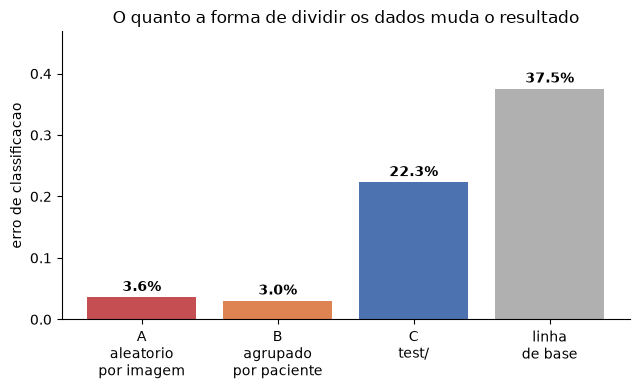

In [7]:
import matplotlib.pyplot as plt

nomes = ['A\naleatorio\npor imagem', 'B\nagrupado\npor paciente', 'C\ntest/', 'linha\nde base']
valores_g = [a, b, erro_C, erro_base]
cores = ['#c44e52', '#dd8452', '#4c72b0', '#b0b0b0']

fig, ax = plt.subplots(figsize=(6.5, 4))
barras = ax.bar(nomes, valores_g, color=cores)
for barra, v in zip(barras, valores_g):
    ax.text(barra.get_x() + barra.get_width()/2, v + .005, '{:.1%}'.format(v),
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('erro de classificacao')
ax.set_title('O quanto a forma de dividir os dados muda o resultado')
ax.set_ylim(0, max(valores_g)*1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Conclusão: não era vazamento por paciente

| protocolo | erro |
|---|---:|
| A) 5-fold aleatório, por imagem | **3,57%** (± 0,72) |
| B) 5-fold agrupado, por paciente | **3,00%** (± 0,37) |
| C) treino completo → `test/` | **22,28%** |
| linha de base (chutar PNEUMONIA) | 37,50% |

**A e B são iguais.** Impedir que o mesmo paciente apareça dos dois lados do
sorteio não piorou o erro em nada — na verdade ele caiu 0,57 ponto, variação menor
que o desvio entre folds. A hipótese de que a validação de 3% era memorização de
radiografias repetidas **está descartada**.

E isso vale mesmo com o agrupamento tendo sido deliberadamente exagerado: a regra
de `paciente()` funde `bacteria` com `virus` no mesmo `personN` e junta as duas
famílias de nome do NORMAL. Um agrupamento *mais rígido* que o real e ainda assim
sem efeito — se houvesse vazamento relevante, teria aparecido aqui.

Duas leituras da saída que podem confundir:

- A linha `fracao do abismo explicada pelo vazamento: -3%` sai **negativa** porque
  B ficou um pouco *abaixo* de A. Não é bug: é a forma aritmética de dizer que o
  vazamento explica **nada** do abismo. A diferença de 0,57 ponto entre A e B é
  menor que o desvio entre folds (0,72), ou seja, ruído.
- O erro de teste aqui é **22,28%**, e o notebook principal reporta **23,08%**. É o
  mesmo pipeline; a diferença é que aqui o protocolo C treina com **100%** do
  `train/`, enquanto o principal treina com 80% (os outros 20% ficam de validação).
  Mais dados de treino, erro um pouco menor.

### O que sobra, então

Se dividir o `train/` de qualquer maneira dá ~3%, e o `test/` dá 22%, é porque as
duas pastas **não são amostras da mesma população**. O `test/` deste dataset foi
montado à parte, com outra curadoria. O modelo aprende muito bem a distribuição do
`train/` e ela simplesmente não é a do `test/`.

### Por que isso importa na prática

1. **A validação interna é inútil para prever desempenho real.** Ela mede acerto
   dentro do `train/`, e isso não transfere. Use sempre o `test/` para reportar.
2. **Ajustar hiperparâmetro contra a validação é otimizar a coisa errada.** Ganhar
   0,5 ponto naquele 3% não diz nada sobre os 22%. Se for tunar, tune medindo no
   `test/` — e aí, com rigor, reserve uma parte dele que você não olha até o fim,
   senão você passa a ajustar contra o teste.
3. **O caminho para melhorar mudou.** Não adianta atacar vazamento, que não existe.
   O alvo é a diferença entre as pastas: normalização por imagem (equalização de
   histograma / CLAHE) para reduzir diferenças de aquisição, aumento de dados mais
   agressivo, ou atributos menos sensíveis ao aparelho — como os embeddings de uma
   CNN pré-treinada.
4. **Como achado de relatório, isso é forte.** É um caso limpo de *distribution
   shift*: o mesmo modelo, medido de dois jeitos defensáveis, dá 3% e 22%. Mostrar
   isso com o experimento controlado vale mais que um número bonito de acurácia.